# M-Lab server usage — เทสต์แต่ละประเทศยิงไปที่เซิร์ฟเวอร์ไหนบ้าง

ดูจาก raw parquet ของทั้ง 9 ประเทศ (`E:/ndt7/mlab_results/mlab_<c>/*.parquet` — raw data ไม่ได้อยู่ใน
repo นี้เพราะใหญ่เกิน ชี้ตรงไปที่ E:/ndt7 แทน) ว่า test แต่ละแถวยิงไปหา
M-Lab server site ไหน (`server_site`, เช่น `bkk01`, `sin01`, `ams05`) แล้ว join กับ
`data/ndt7/<c>/mlab_servers_server_<c>.csv` (หรือ global lookup รวมทุกประเทศ ถ้าประเทศนั้นไม่มี csv
ของตัวเอง เช่น Indonesia) เพื่อเอา city/lat/lon ของ server แต่ละ site มาด้วย

- ไม่แตะ `network_type` / คุณภาพ speed เลย — เล่มนี้ดูแค่ **การกระจายตัวของ server** ที่ client แต่ละประเทศต่อไปหา
- ประเทศ: ไทย (แกน) + 8 เพื่อนบ้าน benchmark (กัมพูชา/ลาว/มาเลเซีย/พม่า/เวียดนาม/ฟิลิปปินส์/อินโดนีเซีย/สิงคโปร์)


## Part 0 · Setup

ชี้ path แบบไม่ขึ้นกับ working directory, เปิด DuckDB connection

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# repo root for data/ndt7/<c>/mlab_servers_server_<c>.csv (this repo)
ROOT = Path.cwd()
while not (ROOT / 'data' / 'ndt7').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# raw M-Lab parquet lives only in E:/ndt7 (never copied here -- too large, ~40GB+ per the
# clean-parquet .gitignore note, raw is bigger still)
RAW_ROOT = Path('E:/ndt7/mlab_results')

# code -> (raw parquet dir under RAW_ROOT, data dir under ROOT/data/ndt7 -- may differ, e.g. Laos)
COUNTRIES = {
    'th': ('th',  'th'),
    'kh': ('kh',  'kh'),
    'la': ('la',  'la'),
    'my': ('my',  'my'),
    'mm': ('mm',  'mm'),
    'vn': ('vn',  'vn'),
    'ph': ('ph',  'ph'),
    'id': ('id',  'id'),    # Indonesia -- no per-country server csv, falls back to the global lookup below
    'sg': ('sg',  'sg'),
}
NAMES = {'th': 'Thailand', 'kh': 'Cambodia', 'la': 'Laos', 'my': 'Malaysia',
         'mm': 'Myanmar', 'vn': 'Vietnam', 'ph': 'Philippines', 'id': 'Indonesia',
         'sg': 'Singapore'}

con = duckdb.connect()
con.execute("SET max_memory='12GB'")
con.execute(f"SET temp_directory='{(ROOT / '.tmp').as_posix()}'")

# M-Lab server_site codes (sin01, hkg03, ...) are global PoPs, not country-specific -- every
# country's mlab_servers_server_*.csv carries the same site catalogue. Indonesia has no such
# csv of its own, so build one global lookup (unioned across all countries that do have one)
# and use it as a fallback for any country missing its own csv.
GLOBAL_SRV_GLOB = (ROOT / 'data' / 'ndt7' / '*' / 'mlab_servers_server_*.csv').as_posix()
assert list(ROOT.glob('data/ndt7/*/mlab_servers_server_*.csv')), f'missing global server csvs: {GLOBAL_SRV_GLOB}'

for code_, (raw_code, data_dir) in COUNTRIES.items():
    raw_glob = RAW_ROOT / f'mlab_{raw_code}' / '*.parquet'
    srv_csv  = ROOT / 'data' / 'ndt7' / data_dir / f'mlab_servers_server_{raw_code}.csv'
    assert list(RAW_ROOT.glob(f'mlab_{raw_code}/*.parquet')), f'missing raw parquet: {raw_glob}'
    if not srv_csv.exists():
        print(f'{code_}: no per-country server csv ({srv_csv.name}) -- will use global lookup')

print(f'ROOT: {ROOT}')
print(f'RAW_ROOT: {RAW_ROOT}')
print(f'{len(COUNTRIES)} countries ready: {list(COUNTRIES)}')

id: no per-country server csv (mlab_servers_server_id.csv) -- will use global lookup
ROOT: E:\thailand-broadband-analysis
RAW_ROOT: E:\ndt7\mlab_results
9 countries ready: ['th', 'kh', 'la', 'my', 'mm', 'vn', 'ph', 'id', 'sg']


## Part 1 · Test count ต่อ server site (ทุกประเทศ)

group by `server_site` จาก raw parquet ของแต่ละประเทศ นับจำนวน test (แถว) ที่ยิงไปแต่ละ site แล้ว join
lat/lon จาก server csv (dedupe เอา 1 แถวต่อ site ด้วย `ROW_NUMBER` เผื่อไฟล์มี coordinate ซ้ำจาก M-Lab
re-survey — วิธีเดียวกับที่ clean notebook ของ TH/PH ใช้)

In [2]:
def server_counts(code_):
    raw_code, data_dir = COUNTRIES[code_]
    raw_glob = (RAW_ROOT / f'mlab_{raw_code}' / '*.parquet').as_posix()
    srv_csv  = ROOT / 'data' / 'ndt7' / data_dir / f'mlab_servers_server_{raw_code}.csv'
    srv_glob = srv_csv.as_posix() if srv_csv.exists() else GLOBAL_SRV_GLOB
    df = con.execute(f"""
        WITH raw AS (
            SELECT server_site, server_city, COUNT(*) AS tests
            FROM read_parquet('{raw_glob}')
            GROUP BY 1, 2
        ),
        srv AS (
            SELECT server_site, server_latitude, server_longitude,
                   ROW_NUMBER() OVER (PARTITION BY server_site ORDER BY server_city) AS rn
            FROM read_csv_auto('{srv_glob}', union_by_name=true)
        )
        SELECT r.server_site, r.server_city, r.tests,
               ROUND(100.0 * r.tests / SUM(r.tests) OVER (), 2) AS pct,
               s.server_latitude, s.server_longitude
        FROM raw r
        LEFT JOIN srv s ON r.server_site = s.server_site AND s.rn = 1
        ORDER BY r.tests DESC
    """).df()
    df.insert(0, 'country', code_)
    return df

by_server = pd.concat([server_counts(c) for c in COUNTRIES], ignore_index=True)

unmatched = by_server[by_server.server_latitude.isna()]
if len(unmatched):
    print(f'WARNING: {len(unmatched)} (country, server_site) rows have no lat/lon match:')
    print(unmatched[['country', 'server_site', 'tests']].to_string(index=False))
else:
    print('every server_site matched a lat/lon in its country server csv')

print(f'{len(by_server):,} (country, server_site) rows total')

every server_site matched a lat/lon in its country server csv
2,177 (country, server_site) rows total


## Part 2 · สรุปภาพรวมต่อประเทศ

จำนวน server site ที่ไม่ซ้ำกัน, server ที่ถูกยิงมากที่สุด (top-1) และสัดส่วน top-3 — ยิ่ง top-1/top-3 สูง
ยิ่งแปลว่า test ของประเทศนั้นกระจุกอยู่ที่ server ไม่กี่ตัว (ไม่ได้กระจายไปหลาย PoP)

In [3]:
summary = (by_server
    .sort_values(['country', 'tests'], ascending=[True, False])
    .groupby('country')
    .apply(lambda g: pd.Series({
        'name': NAMES[g.name],
        'total_tests': g.tests.sum(),
        'unique_servers': len(g),
        'top_server': f"{g.iloc[0].server_site} ({g.iloc[0].server_city})",
        'top1_pct': g.iloc[0].pct,
        'top3_pct': round(g.head(3).pct.sum(), 2),
    }), include_groups=False)
    .loc[list(COUNTRIES)]
    .reset_index())

summary

,country,name,total_tests,unique_servers,top_server,top1_pct,top3_pct
0,th,Thailand,61092929,266,sin01 (Singapore),52.92,79.93
1,kh,Cambodia,785395,222,sin01 (Singapore),66.20,88.71
2,la,Laos,143881,129,hkg03 (Hong Kong),58.28,79.20
3,my,Malaysia,6730391,247,sin01 (Singapore),67.98,88.83
4,mm,Myanmar,2182872,219,maa01 (Chennai),22.68,65.39
5,vn,Vietnam,24927205,262,hkg03 (Hong Kong),47.39,76.40
6,ph,Philippines,265298637,276,mnl02 (Manila),47.95,95.83
7,id,Indonesia,372889942,277,cgk02 (Jakarta),48.29,85.94
8,sg,Singapore,37192041,279,sin01 (Singapore),58.51,80.91


## Part 3 · Top 10 server ต่อประเทศ

In [4]:
for c in COUNTRIES:
    g = by_server[by_server.country == c].head(10)[
        ['server_site', 'server_city', 'tests', 'pct']]
    print(f'--- {NAMES[c]} ({c}) — top {len(g)} of {(by_server.country == c).sum()} servers ---')
    print(g.to_string(index=False))
    print()

--- Thailand (th) — top 10 of 266 servers ---
server_site server_city    tests   pct
      sin01   Singapore 32329591 52.92
      sin02   Singapore  8841260 14.47
      hkg03   Hong Kong  7658434 12.54
      sin03   Singapore  4042769  6.62
      hkg02   Hong Kong  3120702  5.11
      hkg01   Hong Kong  2100387  3.44
      hkg04   Hong Kong  1433724  2.35
      hkg05   Hong Kong   966418  1.58
      cgk01     Jakarta   105914  0.17
      mnl02      Manila   101033  0.17

--- Cambodia (kh) — top 10 of 222 servers ---
server_site server_city  tests   pct
      sin01   Singapore 519955 66.20
      sin02   Singapore 104252 13.27
      sin03   Singapore  72600  9.24
      hkg03   Hong Kong  29978  3.82
      hkg02   Hong Kong  21718  2.77
      hkg01   Hong Kong  11702  1.49
      hkg04   Hong Kong   6543  0.83
      maa01     Chennai   2215  0.28
      mnl01      Manila   2011  0.26
      hkg05   Hong Kong   1937  0.25

--- Laos (la) — top 10 of 129 servers ---
server_site server_city  tes

## Part 4 · แผนภาพ top 8 server ต่อประเทศ

Horizontal bar ของแต่ละประเทศ (% ของ test ทั้งหมดในประเทศนั้นที่ตกที่ server แต่ละตัว) เรียงจากมากไปน้อย

saved -> E:\thailand-broadband-analysis\outputs\ndt7\mlab_server\01_top8_server_share_by_country.png


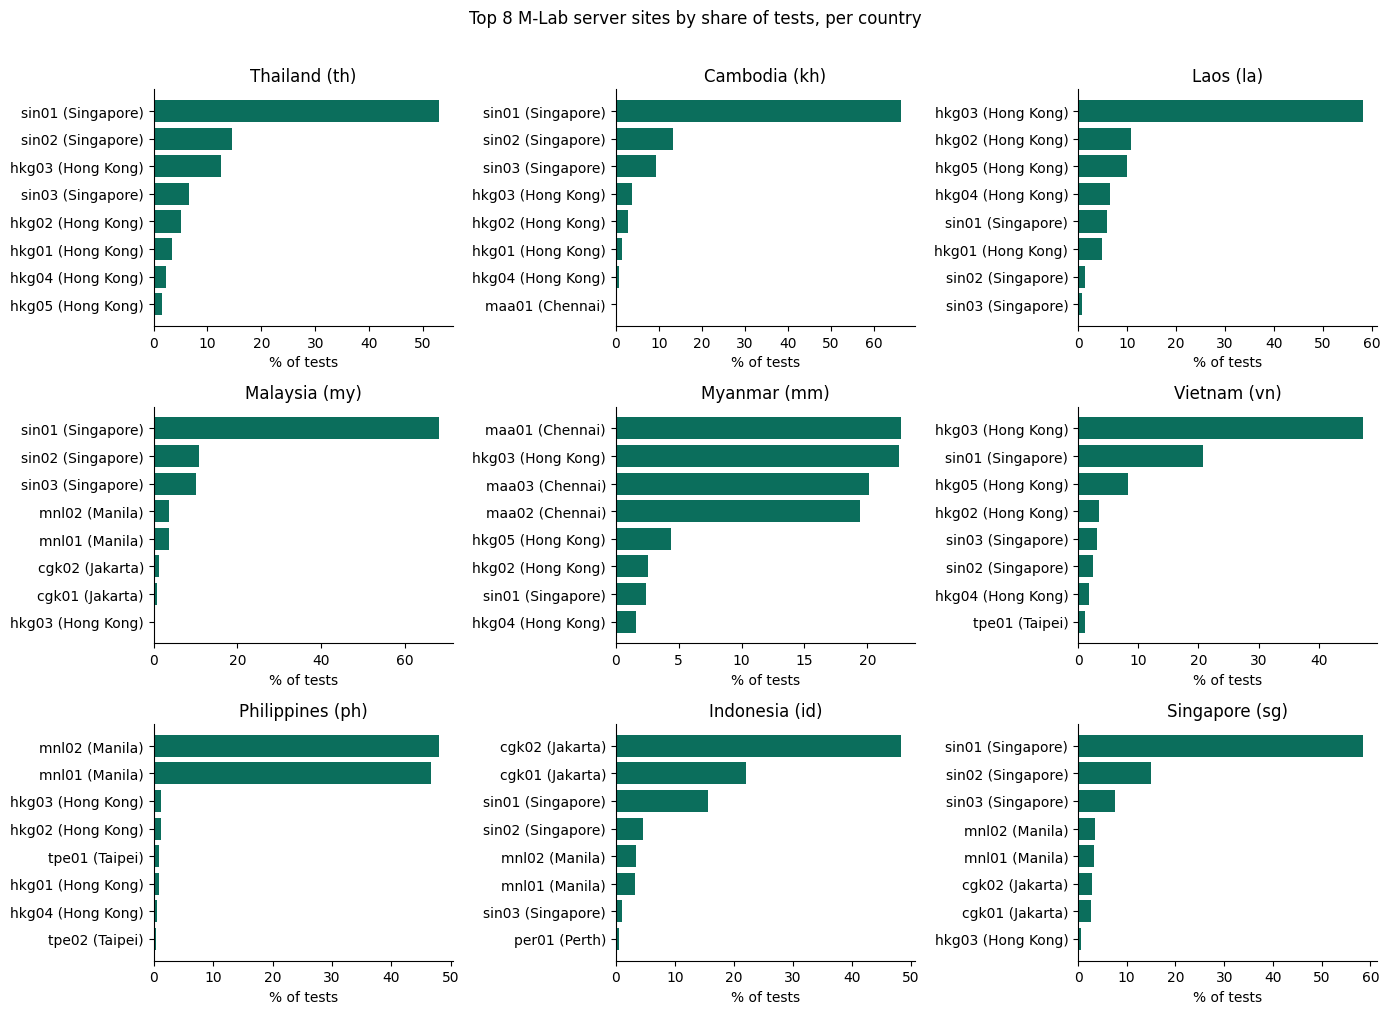

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, c in zip(axes, COUNTRIES):
    g = by_server[by_server.country == c].head(8).iloc[::-1]
    labels = [f'{r.server_site} ({r.server_city})' for r in g.itertuples()]
    ax.barh(labels, g.pct, color='#0B6E5C')
    ax.set_title(f'{NAMES[c]} ({c})')
    ax.set_xlabel('% of tests')
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

for ax in axes[len(COUNTRIES):]:
    ax.axis('off')

fig.suptitle('Top 8 M-Lab server sites by share of tests, per country', y=1.01)
fig.tight_layout()
OUT_PNG = ROOT / 'outputs' / 'ndt7' / 'mlab_server' / '01_top8_server_share_by_country.png'
OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_PNG, dpi=150, bbox_inches='tight')
print(f'saved -> {OUT_PNG}')
plt.show()